# Hồi quy: Dự đoán giá Game Steam

## 1. Mục tiêu
Xây dựng mô hình ước lượng giá tiền của các tựa game (`mat_final_price`) dựa trên 9 đặc trưng không gian PCA.

**Các mô hình thực nghiệm:**
* **Linear Regression** 
* **Random Forest Regressor**

In [2]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sys.path.append('../')
from src.models.regression import train_regression_model
from src.evaluation import evaluate_regression
from src.utils import save_model

df_clean = pd.read_csv('../data/processed/clean_data.csv')
df_pca = pd.read_csv('../data/processed/pca_data.csv')

X = df_pca
y = df_clean['mat_final_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm tra: {X_test.shape}")

Kích thước tập huấn luyện: (191728, 9)
Kích thước tập kiểm tra: (47932, 9)


In [21]:
lr_model = train_regression_model(X_train, y_train, model_type='lr')
y_pred_lr = lr_model.predict(X_test)
lr_metrics = evaluate_regression(y_test, y_pred_lr, model_name="Linear Regression")

--- Linear Regression Regression Metrics ---
RMSE: 76090.0816
MAE:  3075.8033
R2:   0.9879


In [6]:
rf_model = train_regression_model(X_train, y_train, model_type='rf')
y_pred_rf = rf_model.predict(X_test)
rf_metrics = evaluate_regression(y_test, y_pred_rf, model_name="Random Forest")

--- Random Forest Regression Metrics ---
RMSE: 123716.2978
MAE:  1447.1644
R2:   0.9681


C:\Users\Admin\AppData\Local\Temp\ipykernel_19352\68265488.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=mae_scores, palette='viridis', ax=axes[2])


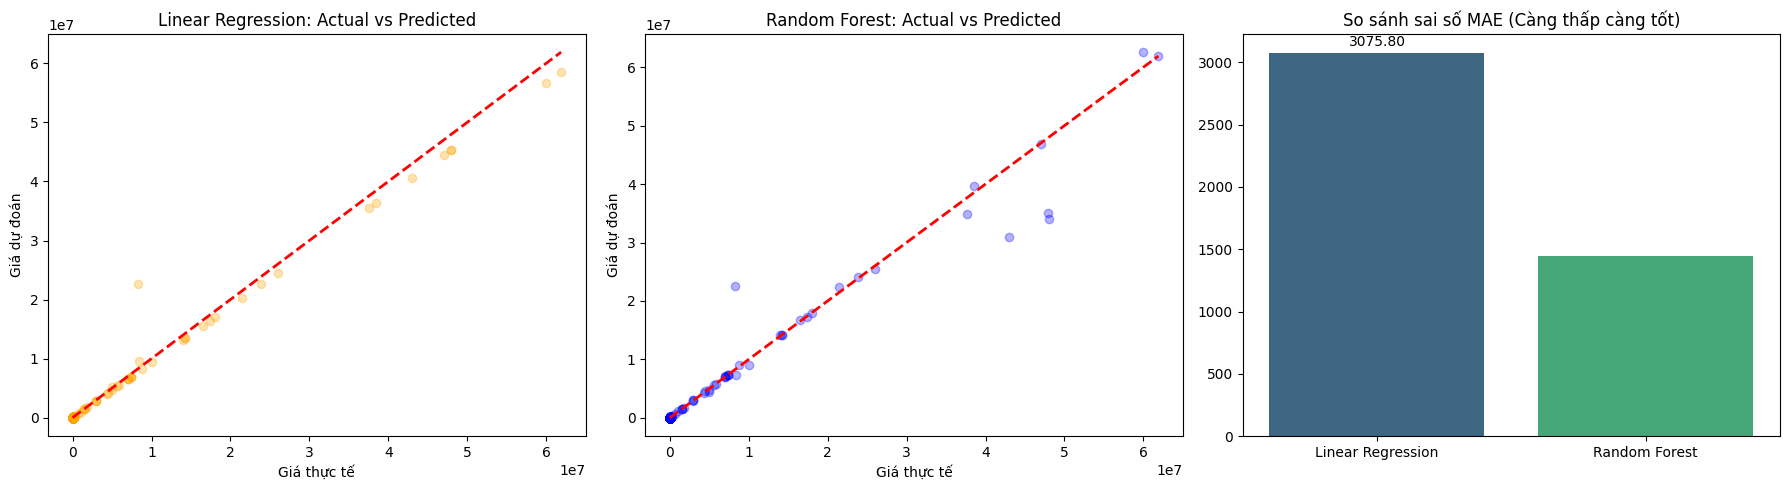

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_lr, alpha=0.3, color='orange')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('Giá thực tế')
axes[0].set_ylabel('Giá dự đoán')

axes[1].scatter(y_test, y_pred_rf, alpha=0.3, color='blue')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
axes[1].set_title('Random Forest: Actual vs Predicted')
axes[1].set_xlabel('Giá thực tế')
axes[1].set_ylabel('Giá dự đoán')

models = ['Linear Regression', 'Random Forest']
mae_scores = [lr_metrics['mae'], rf_metrics['mae']]
sns.barplot(x=models, y=mae_scores, palette='viridis', ax=axes[2])
axes[2].set_title('So sánh sai số MAE (Càng thấp càng tốt)')
axes[2].bar_label(axes[2].containers[0], fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

## 2. Phân tích kết quả và Biểu đồ

Dựa vào các chỉ số và biểu đồ phân tán (Scatter Plot):

* **Linear Regression (Màu cam):** Đạt $R^2$ rất cao (0.9879) và RMSE thấp (76,090). Nhìn vào biểu đồ, các điểm màu cam bám rất sát đường dự đoán đỏ kéo dài đến tận cùng. Do tính chất ngoại suy tuyến tính, mô hình bắt cực tốt các tựa game có giá cao kỷ lục (Outliers). Tuy nhiên, trên mặt bằng chung, sai số tuyệt đối (MAE) lại khá cao (~3075).
* **Random Forest (Màu xanh):** Tối ưu cực tốt ở phân khúc đại trà với **MAE thấp nhất (~1447)** (dự đoán khít cho đa số game). Tuy nhiên, nhìn lên góc phải biểu đồ, với các tựa game giá siêu đắt, các chấm xanh nằm tụt hẳn xuống dưới đường đỏ (dự đoán thấp hơn thực tế rất nhiều). Bản chất thuật toán rừng cây là trung bình hóa các nút lá nên không thể dự đoán tốt các giá trị dị biệt nằm ngoài phổ học, khiến hình phạt RMSE vọt lên tới 123,716.

## 3. Kết luận
Mặc dù Linear Regression bắt Outliers tốt hơn, mô hình **Random Forest Regressor** lại mang giá trị thực tiễn cao hơn vì có sai số MAE thấp nhất cho đại đa số game phổ thông trên thị trường (lệch trung bình chỉ ~14.5 USD).

In [5]:
best_model = rf_model
save_model(best_model, '../src/models/regression_model.pkl')

Model saved to ../src/models/regression_model.pkl
